# 画像に塩ノイズを加える

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sitcv/cv-course3/blob/main/add-noise.ipynb)

In [ ]:
# Colab setup: fetch sample images if missing
import os, urllib.request

BASE = "https://raw.githubusercontent.com/sitcv/cv-course3/main/"
for name in ["lena.png", "scene.png", "jinja.png"]:
    if not os.path.exists(name):
        urllib.request.urlretrieve(BASE + name, name)
        print("downloaded", name)

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [14]:

# 塩コショウのノイズを加える
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)
    total_pixels = image.size
    num_salt = np.ceil(salt_prob * total_pixels)
    num_pepper = np.ceil(pepper_prob * total_pixels)

    # Add salt noise (white pixels)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[coords[0], coords[1], :] = 255

    # Add pepper noise (black pixels)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[coords[0], coords[1], :] = 0

    return noisy_image




In [15]:
# lena.jpg 画像を読み込む
image = cv2.imread('lena.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 関数をテストする
salt_prob = 0.02
pepper_prob = 0.02
noisy_image = add_salt_and_pepper_noise(image, salt_prob, pepper_prob)


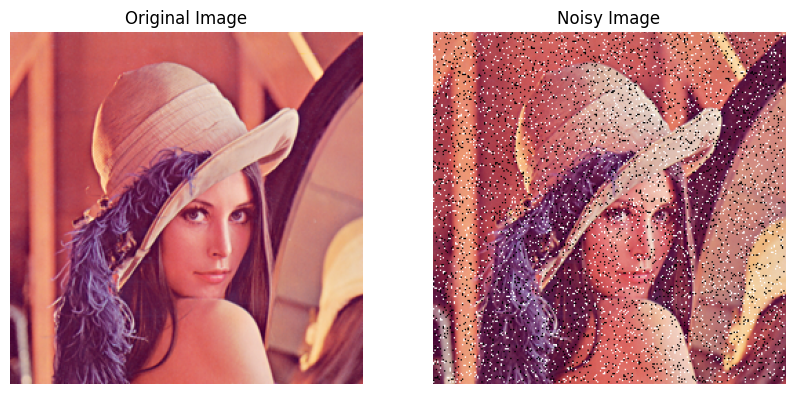

True

In [16]:

# 元の画像とノイズの多い画像を表示する
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_image)
plt.title('Noisy Image')

plt.axis('off')
plt.show()

# ノイズ画像を保存する
cv2.imwrite('noisy_lena.png', cv2.cvtColor(noisy_image, cv2.COLOR_RGB2BGR)) 


In [17]:

# scene.png 画像にノイズを追加して noisy_scene.png として保存する
image = cv2.imread('scene.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
noisy_image = add_salt_and_pepper_noise(image, salt_prob, pepper_prob)
#ノイズ画像を保存する
cv2.imwrite('noisy_scene.png', cv2.cvtColor(noisy_image, cv2.COLOR_RGB2BGR))

# jinja.png 画像にノイズを追加して noisy_jinja.png として保存する
image = cv2.imread('jinja.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
noisy_image = add_salt_and_pepper_noise(image, salt_prob, pepper_prob)
# ノイズ画像を保存する
cv2.imwrite('noisy_jinja.png', cv2.cvtColor(noisy_image, cv2.COLOR_RGB2BGR))

True